In [2]:
!git clone https://github.com/sakanaowo/DragonFruit


fatal: destination path 'DragonFruit' already exists and is not an empty directory.


In [10]:
!git checkout main

M	outputs/model.pth
Switched to branch 'main'
Your branch is up to date with 'origin/main'.


In [3]:
%cd DragonFruit

/kaggle/working/DragonFruit


In [15]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 313 bytes | 313.00 KiB/s, done.
From https://github.com/sakanaowo/DragonFruit
   90d12ea..aa5ab3c  main       -> origin/main
Updating 90d12ea..aa5ab3c
Fast-forward
 utils/transform.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [11]:
!cat src/model.py

import torch
from torchvision import models
import torch.nn as nn

from utils.config import load_config


def build_model(num_classes, pretrained=True):
    model = models.resnet50(pretrained=pretrained)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    return model


def load_model(device):
    config = load_config()
    num_classes=config['model']['num_classes']
    model = build_model(num_classes=num_classes, pretrained=False)

    model.load_state_dict(torch.load(config['model']['model_path']))
    model.to(device)
    model.eval()

    return model


In [16]:
!cat utils/transform.py

# chuẩn hóa ảnh -> tensor theo chuẩn resnet50 pretrained from ImageNet

from torchvision import transforms

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

class ConvertToRGB:
    def __call__(self, img):
        return img.convert("RGB")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    ConvertToRGB(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    ConvertToRGB(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


In [13]:
from PIL import Image
import os

train_dir = '/kaggle/working/DragonFruit/data/train'  # đường dẫn tới folder ảnh

for root, _, files in os.walk(train_dir):
    for f in files:
        if f.lower().endswith(('png', 'jpg', 'jpeg')):
            path = os.path.join(root, f)
            with Image.open(path) as img:
                if img.mode != 'RGB':
                    print(f"Ảnh không phải RGB: {path}, mode = {img.mode}")


In [17]:
!python src/train.py

device: cuda
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50
Train Loss: 0.9236|Train Acc: 62.03%
Val Loss: 0.7038|Val Acc: 71.49%
model saved
Epoch 2/50
Train Loss: 0.7838|Train Acc: 68.90%
Val Loss: 0.7761|Val Acc: 66.09%
Epoch 3/50
Train Loss: 0.7399|Train Acc: 71.34%
Val Loss: 0.6975|Val Acc: 74.34%
model saved
Epoch 4/50
Train Loss: 0.7120|Train Acc: 72.66%
Val Loss: 0.5103|Val Acc: 82.18%
model saved
Epoc

In [19]:
!git pull

remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 28 (delta 13), reused 27 (delta 12), pack-reused 0 (from 0)
Unpacking objects: 100% (28/28), 88.49 MiB | 14.07 MiB/s, done.
From https://github.com/sakanaowo/DragonFruit
   aa5ab3c..5813839  main       -> origin/main
Updating aa5ab3c..5813839
Fast-forward
 .gitignore                 |   1 -
 models/model.pth           | Bin 94373034 -> 98539234 bytes
 outputs/logs/2nd_train.txt | 161 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 src/train.py               |  18 ++++++++
 temp.py                    |  64 --------------------------
 utils/helper.py            |  15 +++---
 utils/log.py               |   3 ++
 utils/plot.py              |  10 +---
 8 files changed, 191 insertions(+), 81 deletions(-)
 create mode 100644 outputs/logs/2nd_train.txt
 delete mode 100644 temp.py
 create mode 100644 utils/log.py


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/kaggle/working/DragonFruit/src/model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the


Accuracy: 85.17%
Classification Report:
                                                 precision    recall  f1-score   support

Fungal Infections (Anthracnose or Stem Canker)       0.92      0.77      0.84       342
                                Healthy Fruits       1.00      0.94      0.97       335
                                Healthy Leaves       0.80      0.95      0.87       188
                        Insect-Infected Fruits       0.41      0.71      0.52        34
                                Sunburn Damage       0.58      0.67      0.63        92

                                      accuracy                           0.85       991
                                     macro avg       0.74      0.81      0.76       991
                                  weighted avg       0.88      0.85      0.86       991



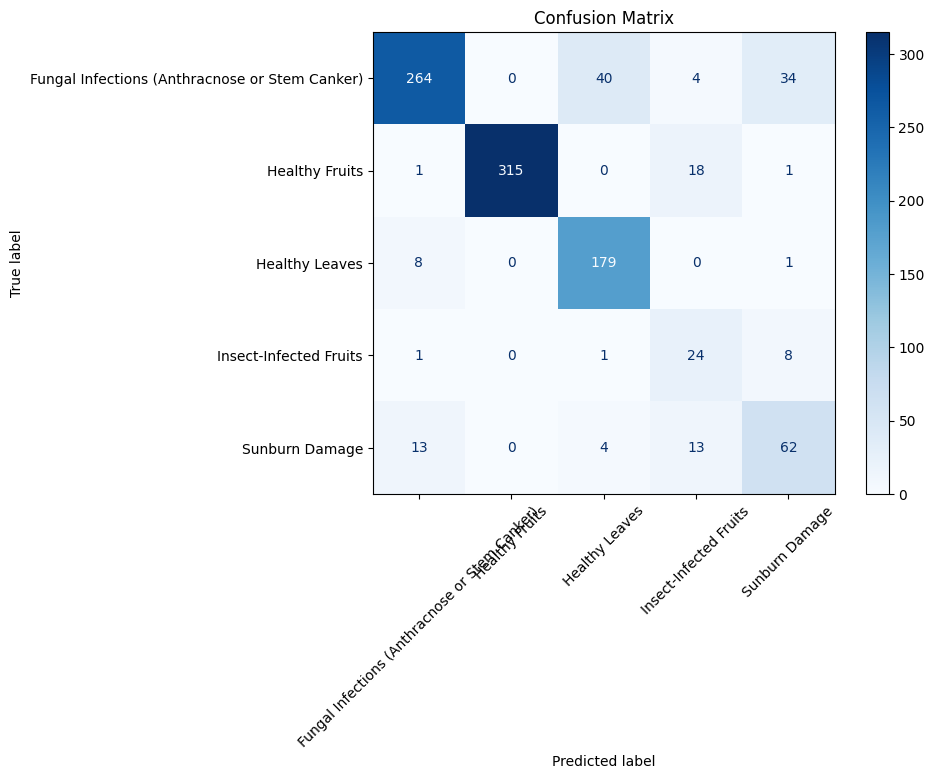

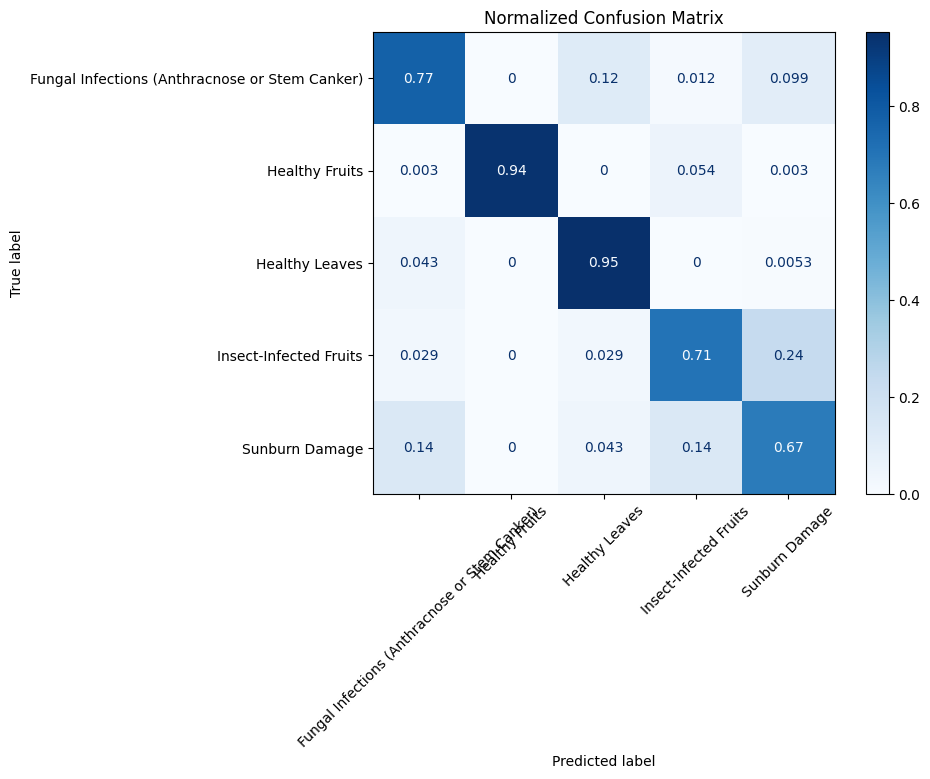

In [22]:
import os
import sys
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Thêm đường dẫn để import module
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

from src.dataset import get_dataloaders
from utils.config import load_config
from src.model import load_model


def evaluate(model, dataloader, device, class_names):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)

    print(f"\nAccuracy: {acc * 100:.2f}%")
    print("Classification Report:\n", report)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

    # Normalized Confusion Matrix
    cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp_norm.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title("Normalized Confusion Matrix")
    plt.show()

    return acc, report


if __name__ == '__main__':
    config = load_config()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model(device)

    dataloader = get_dataloaders(
        config['data']['train_dir'],
        config['data']['val_dir'],
        config['data']['test_dir'],
        config['data']['batch_size'],
        config['data']['num_workers'],
    )
    class_names = config['data']['class_names']
    evaluate(model, dataloader['test'], device, class_names)
